### Chapter 2 Coverage
This chapter covers:
- Exploring the dataset
- Creating a custom dataset
- Splitting the dataset
- Transforming the data
- Creating dataloaders
- Building the classification model
- Defining the loss function
- Defining the optimizer
- Training and evaluation of the model
- Deploying the model
- Model inference on test data

### Exploring the Dataset

In [7]:
import pandas as pd
import matplotlib.pylab as plt
from PIL import Image, ImageDraw
import numpy as np
import os
%matplotlib inline

In [4]:
path2csv = './data/train_labels.csv'

df_labels = pd.read_csv(path2csv)
df_labels.head()

,id,label
0,f38a6374c348f90b587e046aac6079959adf3835,0
1,c18f2d887b7ae4f6742ee445113fa1aef383ed77,1
2,755db6279dae599ebb4d39a9123cce439965282d,0
3,bc3f0c64fb968ff4a8bd33af6971ecae77c75e08,0
4,068aba587a4950175d04c680d38943fd488d6a9d,0


In [5]:
print(df_labels['label'].value_counts())

label
0    130908
1     89117
Name: count, dtype: int64


array([[<Axes: title={'center': 'label'}>]], dtype=object)

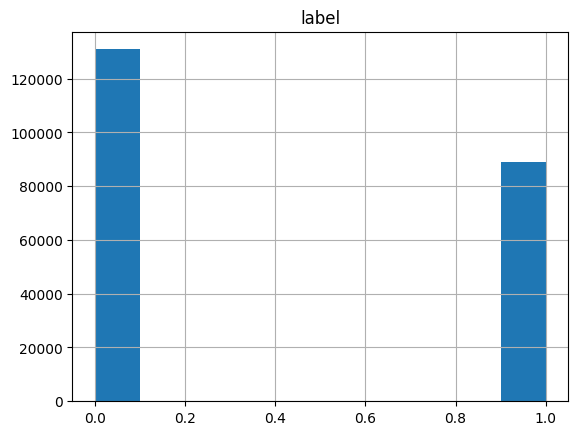

In [6]:
df_labels.hist()

In [ ]:
malignantIDs = df_labels.loc[df_labels['label']==1]['id'].values

In [20]:
path2train = './data/train'
color = False

In [21]:
# Define figure sizes
plt.rcParams['figure.figsize'] = (10.0, 10.0)
plt.subplots_adjust(wspace=0, hspace=0)
nrows,ncols = 3,3

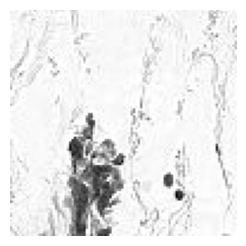

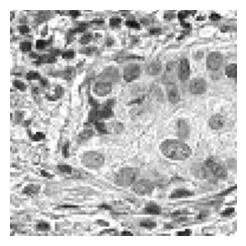

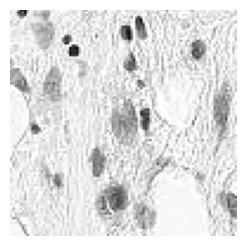

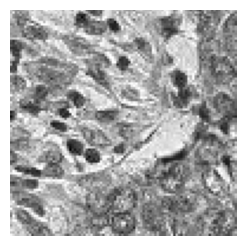

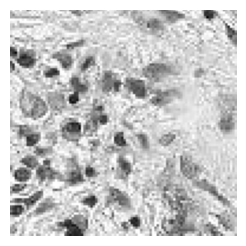

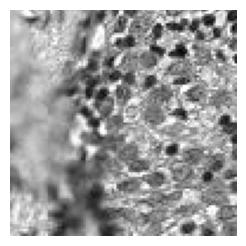

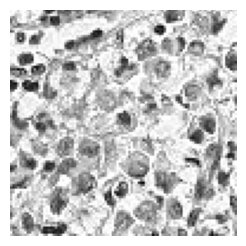

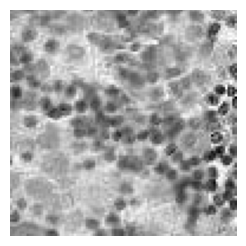

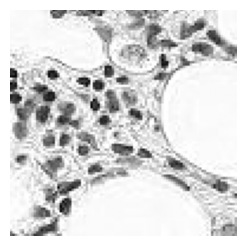

In [23]:
for i,id_ in enumerate(malignantIDs[:nrows*ncols]):
    file_names = os.path.join(path2train, id_ + '.tif')

    # load image
    img = Image.open(file_names)

    # draw 32*32 rectangles
    draw = ImageDraw.Draw(img)
    # draw.rectangle(((32,32), (64,64)), outline='green')
    plt.subplot(nrows,ncols,i+1)
    
    if color == True:
        plt.imshow(np.array(img))
    else:
        plt.imshow(np.array(img)[:,:,0], cmap='gray')
    plt.axis('off')
    plt.show()
    plt.clf()


In [26]:
print("Image shape: ", np.array(img).shape)
print("Image values range from %s to %s", np.array(img).min(), np.array(img).max())

Image shape:  (96, 96, 3)
Image values range from %s to %s 0 255


### Create a Custom Dataset

In [2]:
import torch
from torch.utils.data import Dataset
import torchvision.transforms as transforms

from PIL import Image
import pandas as pd
import os

torch.manual_seed(42)

In [55]:
class histCancerDataset(Dataset):
    
    def __init__(self, data_dir, transform, data_type='train'):

        super().__init__()

        # path to images
        path2data = os.path.join(data_dir, data_type)

        # get list of images
        filenames = os.listdir(path2data)

        # get full path to images
        self.full_filenames = [os.path.join(path2data,f) for f in filenames]

        # labels from train or test .csv
        csv_filename = data_type + '_labels.csv'
        path2csvLabel = os.path.join(data_dir,csv_filename)
        labels_df = pd.read_csv(path2csvLabel)

        labels_df.set_index("id",inplace=True)

        # obtain labels from dataframe
        self.labels = [labels_df.loc[filename[:-4]].values[0] for filename in filenames]
        
        self.transform =transform

    def __len__(self):
        return len(self.full_filenames)
        
    def __getitem__(self, idx):
        # open image apply transforms and return with label

        image = Image.open(self.full_filenames[idx]) # PIL Image
        image = self.transform(image)

        return image, self.labels[idx]
        


In [56]:
import torchvision.transforms as transforms
data_transformer = transforms.Compose([transforms.ToTensor()])

In [57]:
data_dir = './data/'

histo_dataset = histCancerDataset(data_dir=data_dir,transform=data_transformer, data_type='train')

In [58]:
print(histo_dataset.__len__())


220025


In [59]:
img, label = histo_dataset.__getitem__(idx=5)

print(img.shape, torch.min(img), torch.max(img))

torch.Size([3, 96, 96]) tensor(0.) tensor(1.)
